# Regressão Softmax com dados do MNIST

## Objetivo

O objetivo deste notebook é ilustrar o uso de praticamente a mesma rede desenvolvida para a classificação das flores Íris, porém agora com o problema de classificação de dígitos manuscritos utilizando o dataset MNIST.
As principais diferenças são:
- tipo do dado, agora imagem com muito atributos: 28 x 28 pixels
- número de amostras, muito maior, 60 mil
Neste exercício será possível a interpretação do significado dos parâmetros treinados

## Importação das bibliotecas

In [41]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
from torch.autograd import Variable

import torchvision

## Carregamento dos dados do MNIST

In [42]:
! git clone https://github.com/vcasadei/MNIST.git

fatal: destination path 'MNIST' already exists and is not an empty directory.


In [43]:
!ls MNIST

processed  raw


In [44]:
dataset_dir = 'MNIST/'

x_train, y_train = torch.load(dataset_dir + 'processed/training.pt')

print("Amostras de treinamento:", x_train.size(0))

print("\nDimensões dos dados das imagens:   ", x_train.size())
print("Valores mínimo e máximo dos pixels:", torch.min(x_train), torch.max(x_train))
print("Tipo dos dados das imagens:        ", type(x_train))
print("Tipo das classes das imagens:      ", type(y_train))

Amostras de treinamento: 60000

Dimensões dos dados das imagens:    torch.Size([60000, 28, 28])
Valores mínimo e máximo dos pixels: tensor(0, dtype=torch.uint8) tensor(255, dtype=torch.uint8)
Tipo dos dados das imagens:         <class 'torch.Tensor'>
Tipo das classes das imagens:       <class 'torch.Tensor'>


### Carregamento, normalização e seleção dos dados do MNIST

Neste exemplo utilizaremos apenas 1000 amostras de treinamento.

In [45]:
x_train = x_train.float()

x_train = x_train / 255.

if True:
    n_samples_train = 1000

    x_train = x_train[:n_samples_train]
    y_train = y_train[:n_samples_train]

print("Amostras de treinamento:", x_train.size(0))

print("\nDimensões dos dados das imagens:   ", x_train.size())
print("Valores mínimo e máximo dos pixels:", torch.min(x_train), torch.max(x_train))
print("Tipo dos dados das imagens:        ", type(x_train))
print("Tipo das classes das imagens:      ", type(y_train))

Amostras de treinamento: 1000

Dimensões dos dados das imagens:    torch.Size([1000, 28, 28])
Valores mínimo e máximo dos pixels: tensor(0.) tensor(1.)
Tipo dos dados das imagens:         <class 'torch.Tensor'>
Tipo das classes das imagens:       <class 'torch.Tensor'>


### Carregamento e normalização dos dados de validação

In [46]:
x_val, y_val = torch.load(dataset_dir + 'processed/test.pt')

x_val = x_val.float()
x_val = x_val / 255.

# Limit validation samples for consistency with training set, if needed
# If you want to use the full test set for validation, comment this block
if True:
    n_samples_val = 200 # Using a smaller validation set for demonstration

    x_val = x_val[:n_samples_val]
    y_val = y_val[:n_samples_val]

print("Amostras de validação:", x_val.size(0))

print("\nDimensões dos dados das imagens de validação:   ", x_val.size())
print("Valores mínimo e máximo dos pixels de validação:", torch.min(x_val), torch.max(x_val))
print("Tipo dos dados das imagens de validação:        ", type(x_val))
print("Tipo das classes das imagens de validação:      ", type(y_val))

Amostras de validação: 200

Dimensões dos dados das imagens de validação:    torch.Size([200, 28, 28])
Valores mínimo e máximo dos pixels de validação: tensor(0.) tensor(1.)
Tipo dos dados das imagens de validação:         <class 'torch.Tensor'>
Tipo das classes das imagens de validação:       <class 'torch.Tensor'>


### Visualizando os dados

(np.float64(-0.5), np.float64(232.5), np.float64(87.5), np.float64(-0.5))

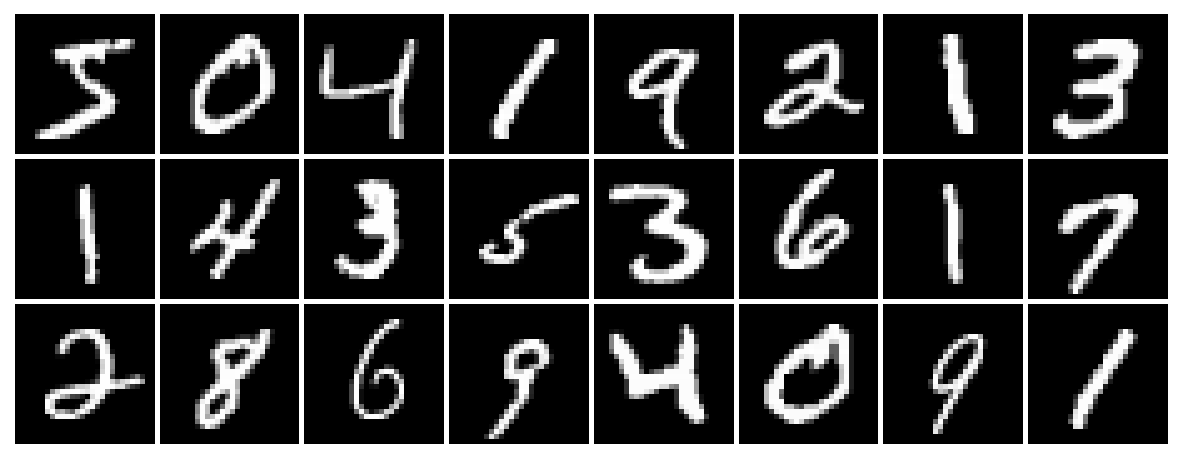

In [47]:
n_samples = 24

# cria um grid com as imagens
grid = torchvision.utils.make_grid(x_train[:n_samples].unsqueeze(dim=1), pad_value=1.0, padding=1)

plt.figure(figsize=(15, 10))
plt.imshow(grid.numpy().transpose(1, 2, 0))
plt.axis('off')

### Visualizando uma imagem com o matplotlib

class: tensor(5)


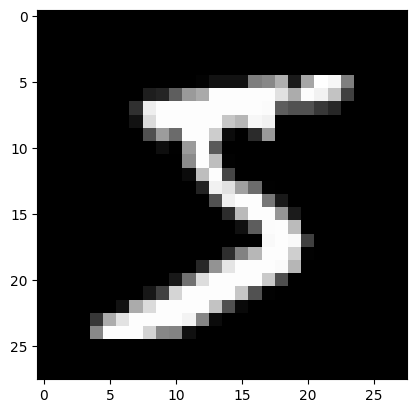

In [48]:
image  = x_train[0]
target = y_train[0]

plt.imshow(image.numpy(), cmap='gray')
print('class:', target)

## Modelo

In [49]:
model = torch.nn.Linear(28*28, 10) # 28*28 atributos de entrada e 10 neurônios na sáida

### Testando um predict com poucas amostras

In [50]:
xin = x_train[:5].view(-1,28*28)
score = model(Variable(xin))
score

tensor([[-0.2955,  0.1058,  0.1758, -0.0511, -0.1910,  0.1812,  0.2614,  0.1709,
         -0.0223,  0.2879],
        [-0.1160, -0.0528,  0.2294,  0.0931, -0.2345,  0.3924,  0.1353,  0.1667,
          0.0398,  0.3253],
        [ 0.2975, -0.1126,  0.2067, -0.0875,  0.1109,  0.2032, -0.0770,  0.2813,
          0.2421, -0.0048],
        [-0.3016,  0.0872,  0.3209,  0.0585,  0.0312, -0.0077,  0.0843,  0.3472,
          0.0422,  0.2598],
        [-0.0982, -0.1897,  0.1513,  0.1758, -0.2325,  0.0250, -0.2735,  0.0554,
         -0.0560,  0.2032]], grad_fn=<AddmmBackward0>)

## Treinamento

### Inicialização dos parâmetros

In [51]:
epochs = 100
learningRate = 0.5

# Utilizaremos CrossEntropyLoss como função de perda
criterion = torch.nn.CrossEntropyLoss()

# Gradiente descendente
optimizer = torch.optim.SGD(model.parameters(), lr=learningRate)

### Laço de treinamento dos pesos

Epoch [1/100], Loss: 0.178355, Acc: 0.967000


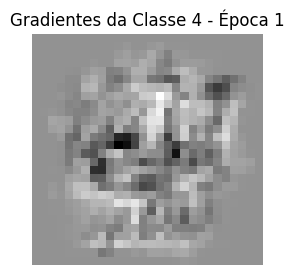

Epoch [2/100], Loss: 0.177780, Acc: 0.967000


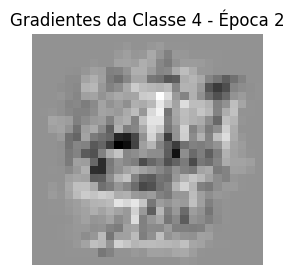

Epoch [3/100], Loss: 0.177209, Acc: 0.967000


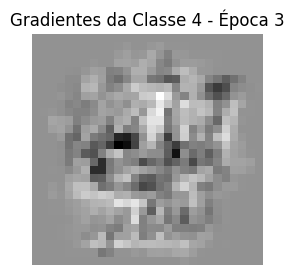

Epoch [4/100], Loss: 0.176641, Acc: 0.967000


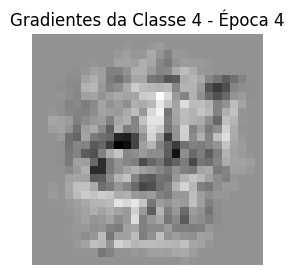

Epoch [5/100], Loss: 0.176077, Acc: 0.967000


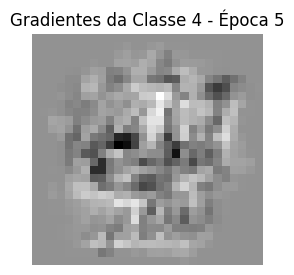

Epoch [6/100], Loss: 0.175516, Acc: 0.967000


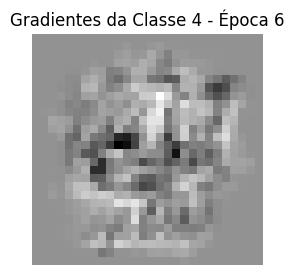

Epoch [7/100], Loss: 0.174958, Acc: 0.967000


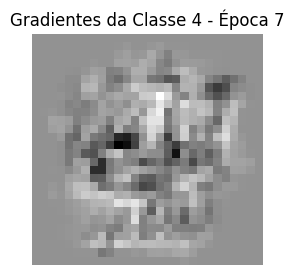

Epoch [8/100], Loss: 0.174404, Acc: 0.967000


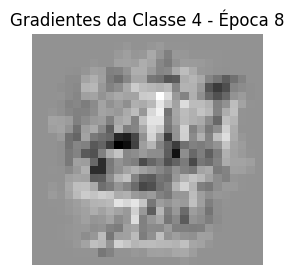

Epoch [9/100], Loss: 0.173854, Acc: 0.967000


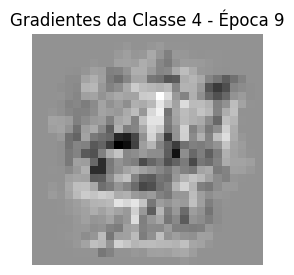

Epoch [10/100], Loss: 0.173306, Acc: 0.967000


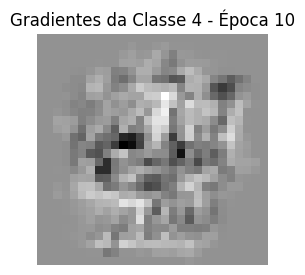

Epoch [11/100], Loss: 0.172762, Acc: 0.967000


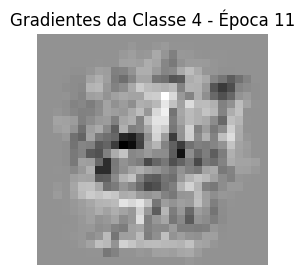

Epoch [12/100], Loss: 0.172221, Acc: 0.967000


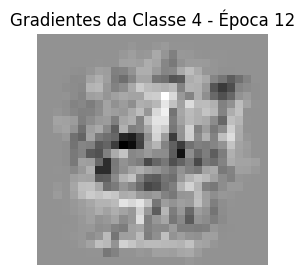

Epoch [13/100], Loss: 0.171683, Acc: 0.967000


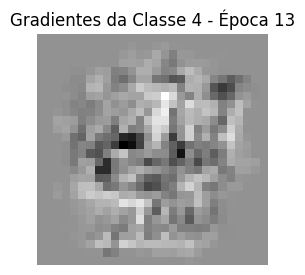

Epoch [14/100], Loss: 0.171149, Acc: 0.967000


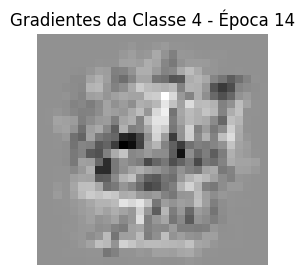

Epoch [15/100], Loss: 0.170617, Acc: 0.967000


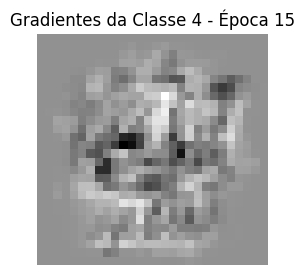

Epoch [16/100], Loss: 0.170089, Acc: 0.967000


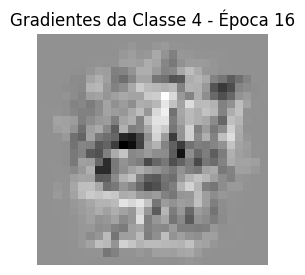

Epoch [17/100], Loss: 0.169564, Acc: 0.968000


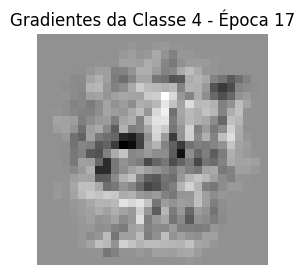

Epoch [18/100], Loss: 0.169042, Acc: 0.968000


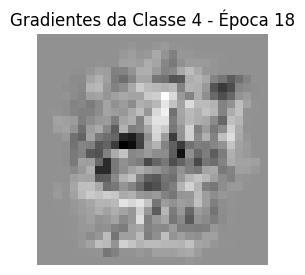

Epoch [19/100], Loss: 0.168523, Acc: 0.968000


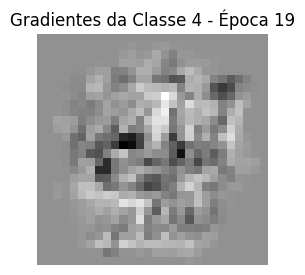

Epoch [20/100], Loss: 0.168006, Acc: 0.968000


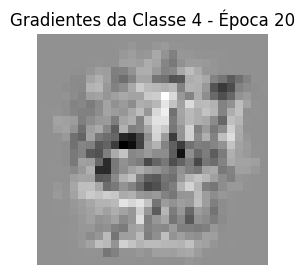

Epoch [21/100], Loss: 0.167493, Acc: 0.968000


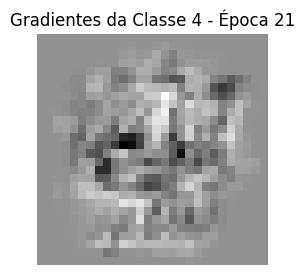

Epoch [22/100], Loss: 0.166983, Acc: 0.968000


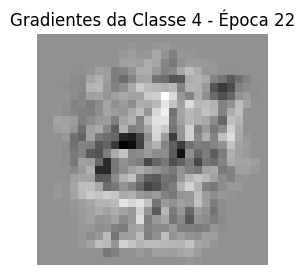

Epoch [23/100], Loss: 0.166476, Acc: 0.968000


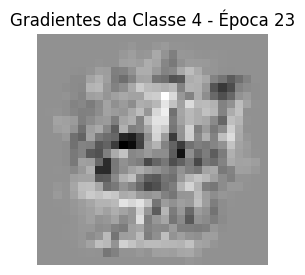

Epoch [24/100], Loss: 0.165971, Acc: 0.969000


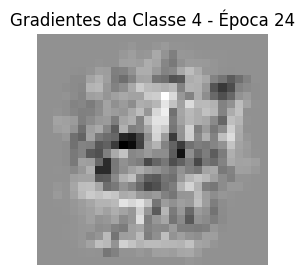

Epoch [25/100], Loss: 0.165470, Acc: 0.970000


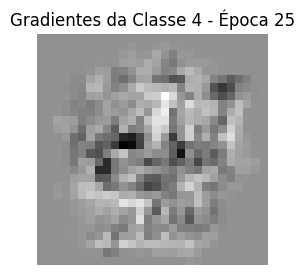

Epoch [26/100], Loss: 0.164971, Acc: 0.970000


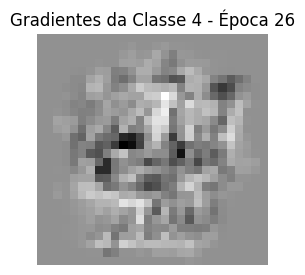

Epoch [27/100], Loss: 0.164475, Acc: 0.970000


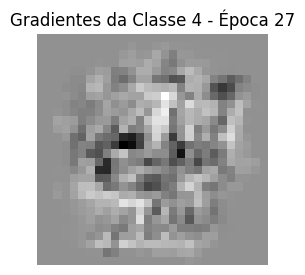

Epoch [28/100], Loss: 0.163982, Acc: 0.970000


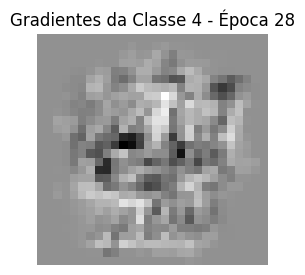

Epoch [29/100], Loss: 0.163492, Acc: 0.970000


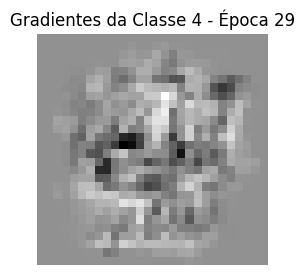

Epoch [30/100], Loss: 0.163005, Acc: 0.970000


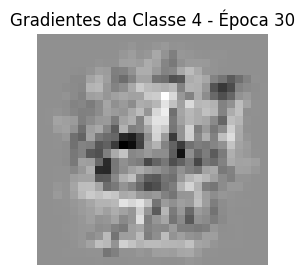

Epoch [31/100], Loss: 0.162520, Acc: 0.970000


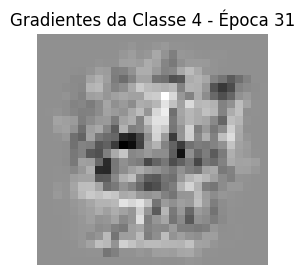

Epoch [32/100], Loss: 0.162037, Acc: 0.970000


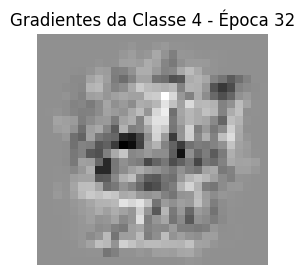

Epoch [33/100], Loss: 0.161558, Acc: 0.970000


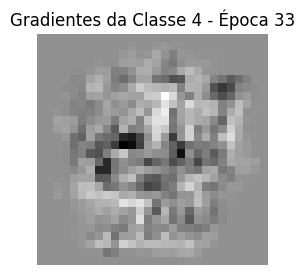

Epoch [34/100], Loss: 0.161081, Acc: 0.970000


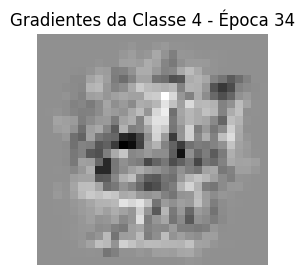

Epoch [35/100], Loss: 0.160607, Acc: 0.970000


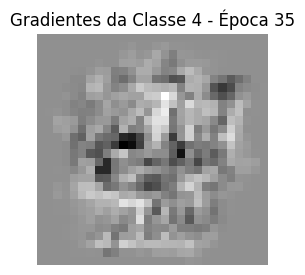

Epoch [36/100], Loss: 0.160135, Acc: 0.970000


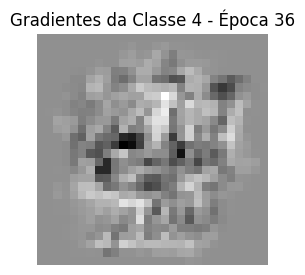

Epoch [37/100], Loss: 0.159666, Acc: 0.970000


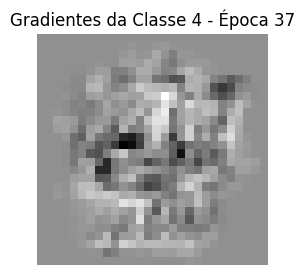

Epoch [38/100], Loss: 0.159200, Acc: 0.971000


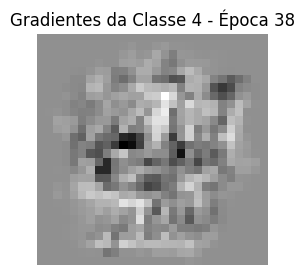

Epoch [39/100], Loss: 0.158735, Acc: 0.972000


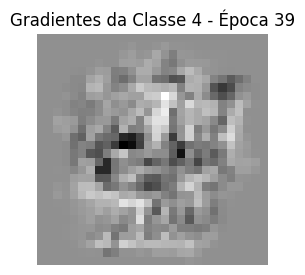

Epoch [40/100], Loss: 0.158274, Acc: 0.973000


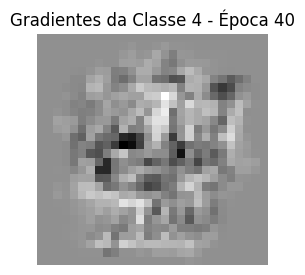

Epoch [41/100], Loss: 0.157815, Acc: 0.973000


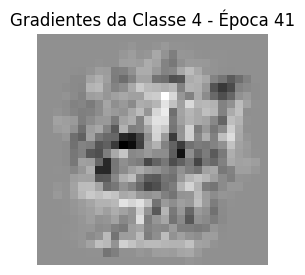

Epoch [42/100], Loss: 0.157358, Acc: 0.973000


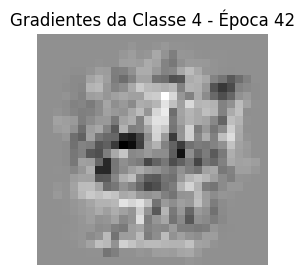

Epoch [43/100], Loss: 0.156904, Acc: 0.973000


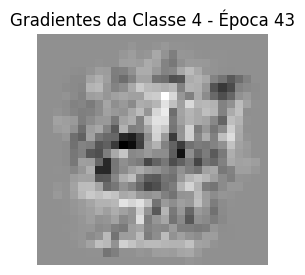

Epoch [44/100], Loss: 0.156453, Acc: 0.973000


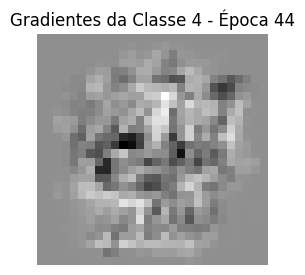

Epoch [45/100], Loss: 0.156003, Acc: 0.973000


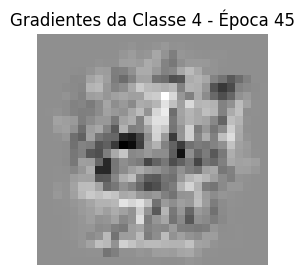

Epoch [46/100], Loss: 0.155556, Acc: 0.973000


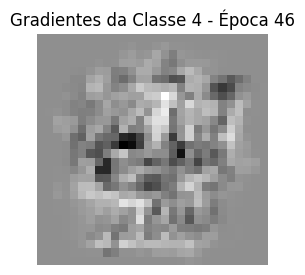

Epoch [47/100], Loss: 0.155112, Acc: 0.973000


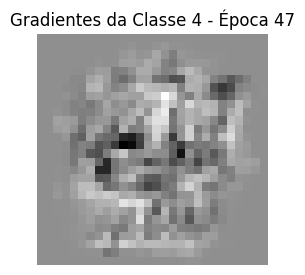

Epoch [48/100], Loss: 0.154669, Acc: 0.973000


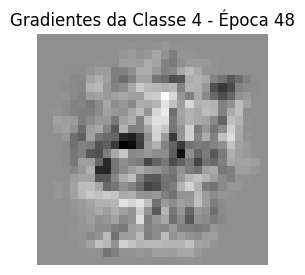

Epoch [49/100], Loss: 0.154229, Acc: 0.974000


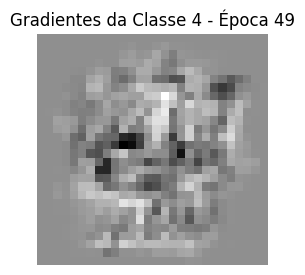

Epoch [50/100], Loss: 0.153792, Acc: 0.975000


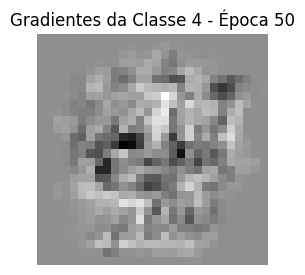

Epoch [51/100], Loss: 0.153356, Acc: 0.975000


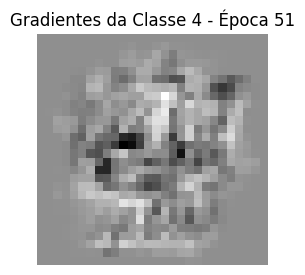

Epoch [52/100], Loss: 0.152923, Acc: 0.975000


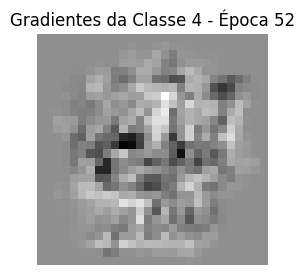

Epoch [53/100], Loss: 0.152493, Acc: 0.975000


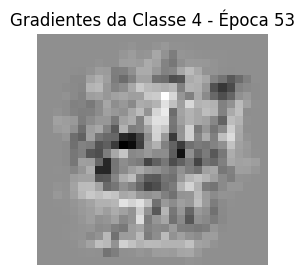

Epoch [54/100], Loss: 0.152064, Acc: 0.975000


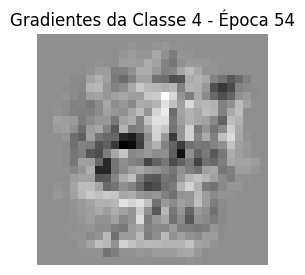

Epoch [55/100], Loss: 0.151638, Acc: 0.975000


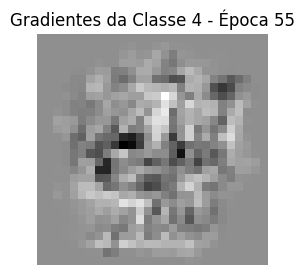

Epoch [56/100], Loss: 0.151213, Acc: 0.975000


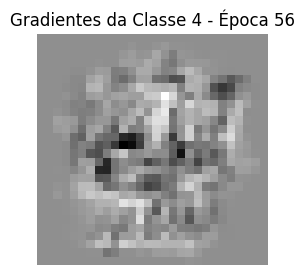

Epoch [57/100], Loss: 0.150791, Acc: 0.975000


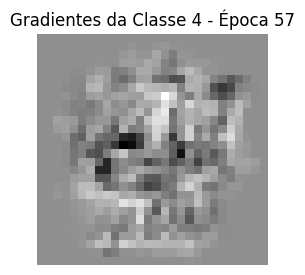

Epoch [58/100], Loss: 0.150371, Acc: 0.975000


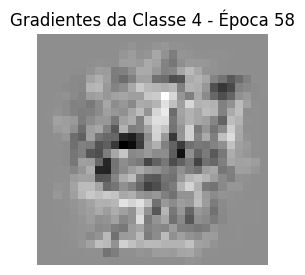

Epoch [59/100], Loss: 0.149954, Acc: 0.975000


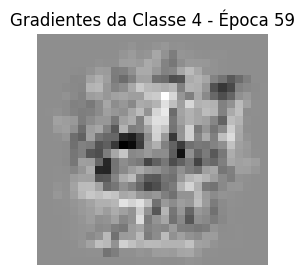

Epoch [60/100], Loss: 0.149538, Acc: 0.975000


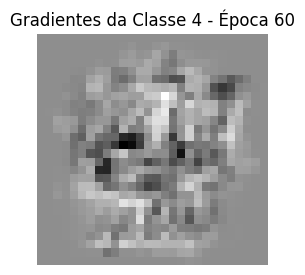

Epoch [61/100], Loss: 0.149124, Acc: 0.975000


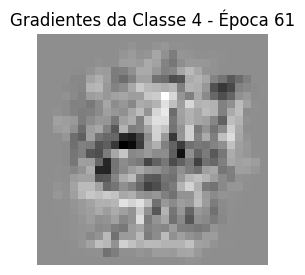

Epoch [62/100], Loss: 0.148713, Acc: 0.975000


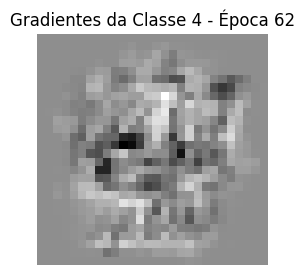

Epoch [63/100], Loss: 0.148304, Acc: 0.975000


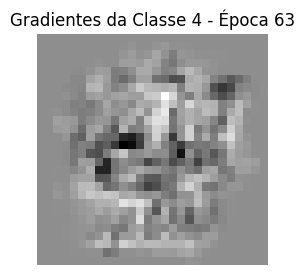

Epoch [64/100], Loss: 0.147896, Acc: 0.975000


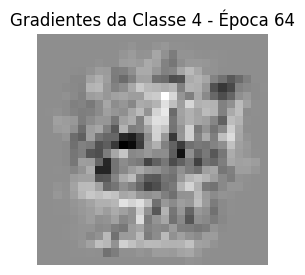

Epoch [65/100], Loss: 0.147491, Acc: 0.975000


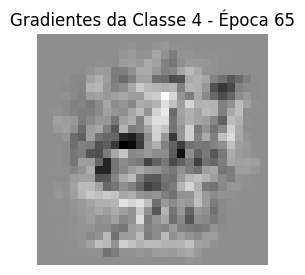

Epoch [66/100], Loss: 0.147088, Acc: 0.975000


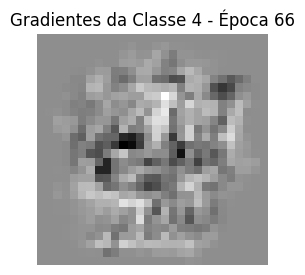

Epoch [67/100], Loss: 0.146686, Acc: 0.975000


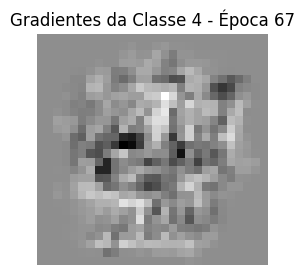

Epoch [68/100], Loss: 0.146287, Acc: 0.975000


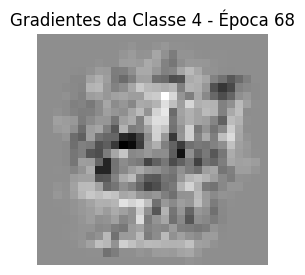

Epoch [69/100], Loss: 0.145890, Acc: 0.975000


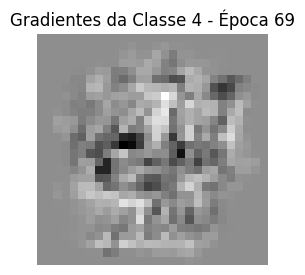

Epoch [70/100], Loss: 0.145494, Acc: 0.975000


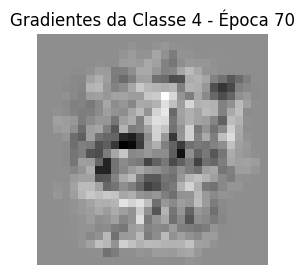

Epoch [71/100], Loss: 0.145101, Acc: 0.975000


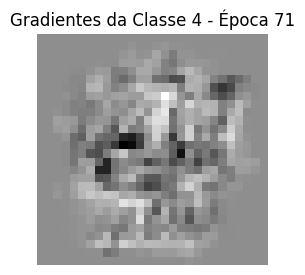

Epoch [72/100], Loss: 0.144710, Acc: 0.975000


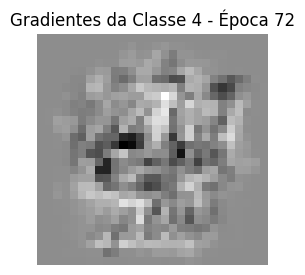

Epoch [73/100], Loss: 0.144320, Acc: 0.975000


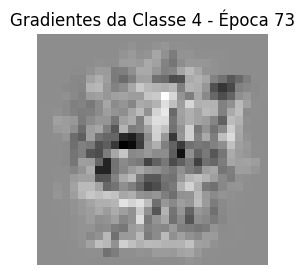

Epoch [74/100], Loss: 0.143932, Acc: 0.975000


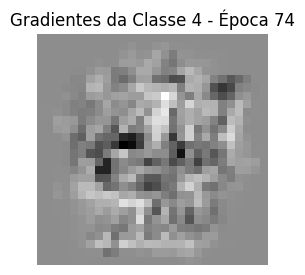

Epoch [75/100], Loss: 0.143547, Acc: 0.975000


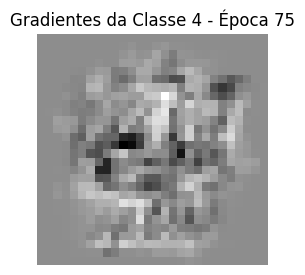

Epoch [76/100], Loss: 0.143163, Acc: 0.975000


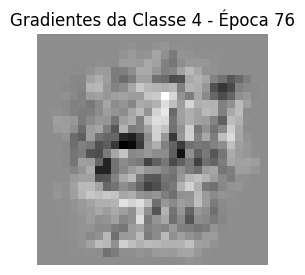

Epoch [77/100], Loss: 0.142781, Acc: 0.975000


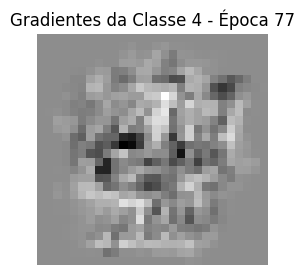

Epoch [78/100], Loss: 0.142401, Acc: 0.975000


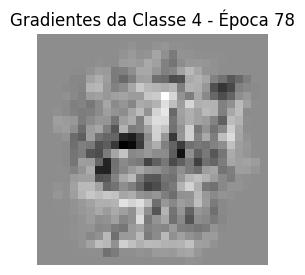

Epoch [79/100], Loss: 0.142022, Acc: 0.975000


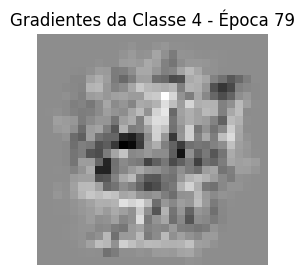

Epoch [80/100], Loss: 0.141646, Acc: 0.975000


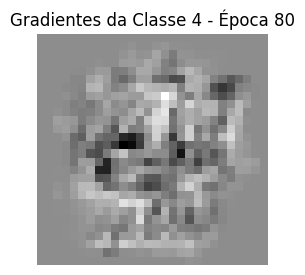

Epoch [81/100], Loss: 0.141271, Acc: 0.976000


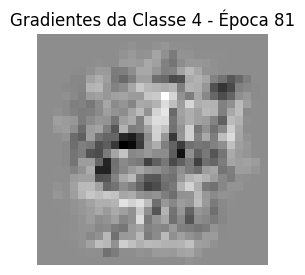

Epoch [82/100], Loss: 0.140898, Acc: 0.976000


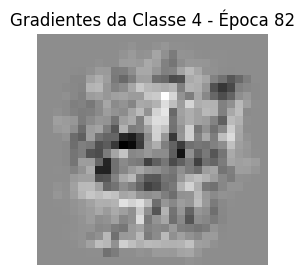

Epoch [83/100], Loss: 0.140527, Acc: 0.976000


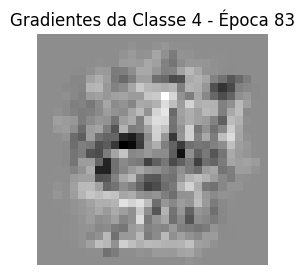

Epoch [84/100], Loss: 0.140158, Acc: 0.976000


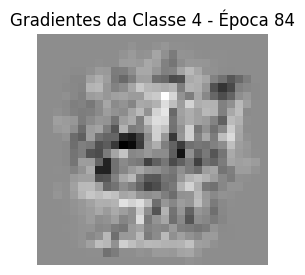

Epoch [85/100], Loss: 0.139790, Acc: 0.976000


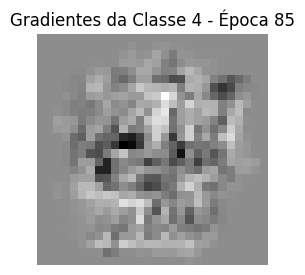

Epoch [86/100], Loss: 0.139424, Acc: 0.976000


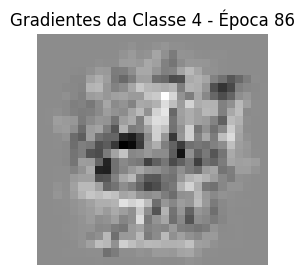

Epoch [87/100], Loss: 0.139060, Acc: 0.976000


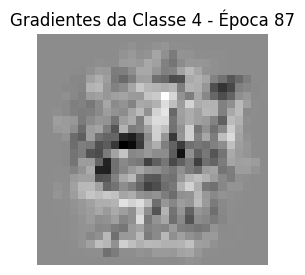

Epoch [88/100], Loss: 0.138698, Acc: 0.976000


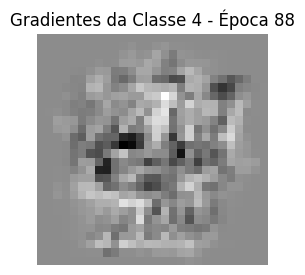

Epoch [89/100], Loss: 0.138337, Acc: 0.976000


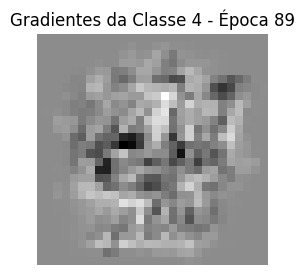

Epoch [90/100], Loss: 0.137978, Acc: 0.976000


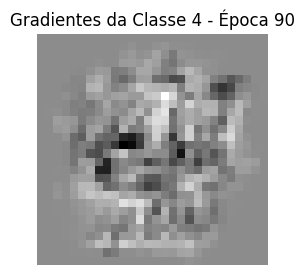

Epoch [91/100], Loss: 0.137620, Acc: 0.976000


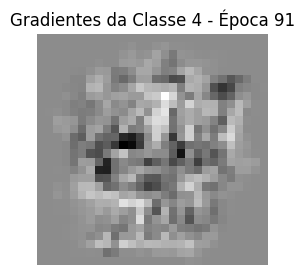

Epoch [92/100], Loss: 0.137265, Acc: 0.976000


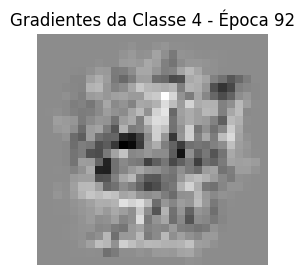

Epoch [93/100], Loss: 0.136911, Acc: 0.976000


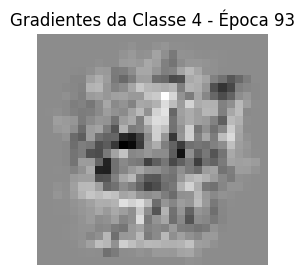

Epoch [94/100], Loss: 0.136558, Acc: 0.976000


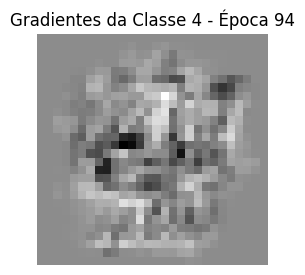

Epoch [95/100], Loss: 0.136208, Acc: 0.977000


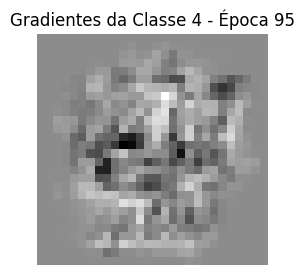

Epoch [96/100], Loss: 0.135859, Acc: 0.977000


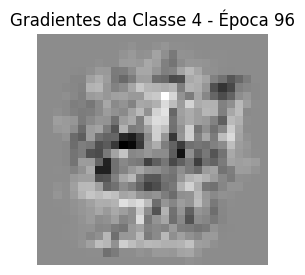

Epoch [97/100], Loss: 0.135511, Acc: 0.977000


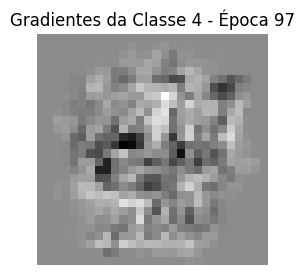

Epoch [98/100], Loss: 0.135165, Acc: 0.977000


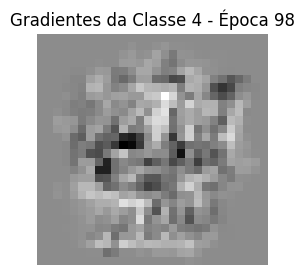

Epoch [99/100], Loss: 0.134821, Acc: 0.977000


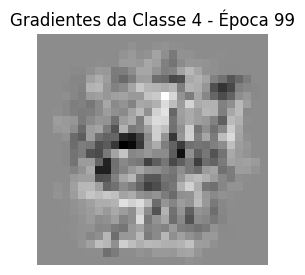

Epoch [100/100], Loss: 0.134478, Acc: 0.977000


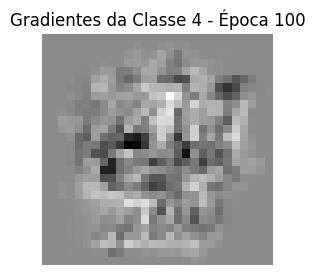

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

losses = []
zs = []

for i in range(epochs):
    inputs = Variable(x_train.view(-1, 28 * 28))
    outputs = model(inputs)

    zs.append(outputs[1].detach().numpy())

    loss = criterion(outputs, Variable(y_train))

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    _, predicts = torch.max(outputs, 1)

    y_pred = predicts.data
    accuracy = (y_pred.numpy() == y_train.numpy()).mean()
    
    # ---------------------------------------------------------
    # 1) Imprimir o número da época, a perda e a acurácia
    # ---------------------------------------------------------
    print(f'Epoch [{i+1}/{epochs}], Loss: {loss.item():.6f}, Acc: {accuracy:.6f}')
    
    # ---------------------------------------------------------
    # 2) Visualização dos gradientes para a classe do dígito 4
    # ---------------------------------------------------------
    gradientes_digito_4 = model.weight.grad[4, :].detach().numpy()
    
    plt.figure(figsize=(3, 3))
    plt.imshow(gradientes_digito_4.reshape((28, 28)), cmap='gray')
    plt.title(f'Gradientes da Classe 4 - Época {i+1}')
    plt.axis('off')
    plt.show()

### Laço de treinamento dos pesos (com validação e armazenamento de métricas)

In [53]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for i in range(epochs):
    # Passada de treinamento
    inputs_train = Variable(x_train.view(-1, 28 * 28))
    outputs_train = model(inputs_train)
    loss_train = criterion(outputs_train, Variable(y_train))

    # Zero, backpropagation, ajusta parâmetros pelo gradiente descendente
    optimizer.zero_grad()
    loss_train.backward()
    optimizer.step()

    train_losses.append(loss_train.item())

    _, predicts_train = torch.max(outputs_train, 1)
    accuracy_train = (predicts_train.data.numpy() == y_train.numpy()).mean()
    train_accuracies.append(accuracy_train)

    # Passada de validação
    with torch.no_grad(): # Desabilita o cálculo de gradientes para validação
        inputs_val = Variable(x_val.view(-1, 28 * 28))
        outputs_val = model(inputs_val)
        loss_val = criterion(outputs_val, Variable(y_val))
        val_losses.append(loss_val.item())

        _, predicts_val = torch.max(outputs_val, 1)
        accuracy_val = (predicts_val.data.numpy() == y_val.numpy()).mean()
        val_accuracies.append(accuracy_val)

    print(f'Epoch [{i+1}/{epochs}], ' \
          f'Train Loss: {loss_train.item():.4f}, ' \
          f'Train Acc: {accuracy_train:.4f}, ' \
          f'Val Loss: {loss_val.item():.4f}, ' \
          f'Val Acc: {accuracy_val:.4f}')

Epoch [1/100], Train Loss: 0.2644, Train Acc: 0.9430, Val Loss: 0.3938, Val Acc: 0.9050
Epoch [2/100], Train Loss: 0.2631, Train Acc: 0.9430, Val Loss: 0.3929, Val Acc: 0.9050
Epoch [3/100], Train Loss: 0.2618, Train Acc: 0.9440, Val Loss: 0.3919, Val Acc: 0.9050
Epoch [4/100], Train Loss: 0.2605, Train Acc: 0.9450, Val Loss: 0.3910, Val Acc: 0.9050
Epoch [5/100], Train Loss: 0.2592, Train Acc: 0.9450, Val Loss: 0.3900, Val Acc: 0.9050
Epoch [6/100], Train Loss: 0.2580, Train Acc: 0.9450, Val Loss: 0.3891, Val Acc: 0.9050
Epoch [7/100], Train Loss: 0.2567, Train Acc: 0.9450, Val Loss: 0.3883, Val Acc: 0.9050
Epoch [8/100], Train Loss: 0.2555, Train Acc: 0.9450, Val Loss: 0.3874, Val Acc: 0.9050
Epoch [9/100], Train Loss: 0.2543, Train Acc: 0.9450, Val Loss: 0.3865, Val Acc: 0.9050
Epoch [10/100], Train Loss: 0.2531, Train Acc: 0.9450, Val Loss: 0.3857, Val Acc: 0.9050
Epoch [11/100], Train Loss: 0.2519, Train Acc: 0.9450, Val Loss: 0.3849, Val Acc: 0.9050
Epoch [12/100], Train Loss: 0.

In [54]:
print('Final loss:', loss.item())

Final loss: 0.26576608419418335


### Visualizando gráfico de perda durante o treinamento

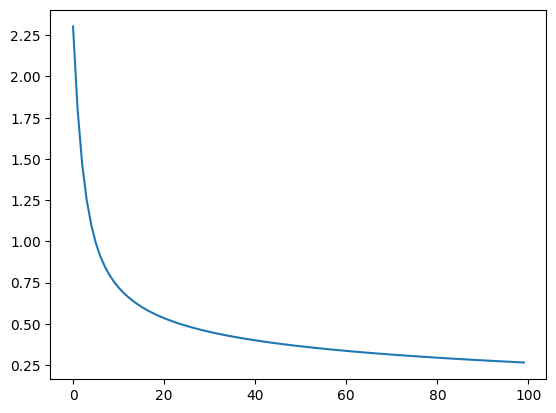

In [55]:
plt.plot(losses)

### Visualizando gráficos de perda e acurácia durante o treinamento

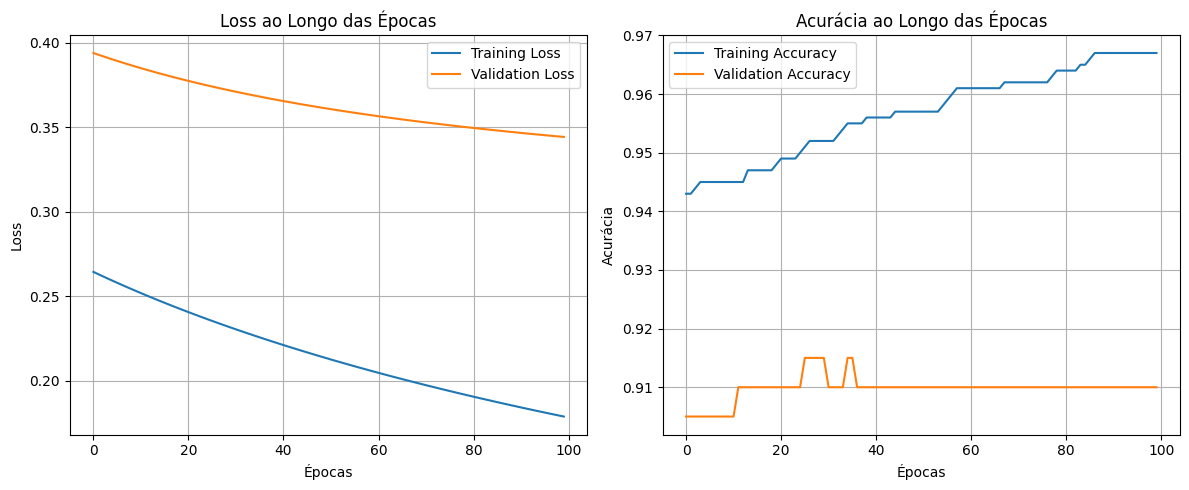

In [56]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Loss ao Longo das Épocas')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Training Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.title('Acurácia ao Longo das Épocas')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Avaliação

### Acurácia tanto no conjunto de treinamento como no conjunto de testes

In [57]:
def predict(model, input_data):
    outputs = model(Variable(input_data))
    _, predicts = torch.max(outputs, 1)

    return predicts.data

y_pred = predict(model, x_train.view(-1, 28*28))
accuracy = (y_pred.numpy() == y_train.numpy()).mean()
print('Accuracy:', accuracy)

Accuracy: 0.967


### Matriz de confusão com dados de treinamento e teste

In [58]:
print('Matriz de confusão:')
pd.crosstab(y_pred.numpy(), y_train.numpy())

Matriz de confusão:


col_0,0,1,2,3,4,5,6,7,8,9
row_0,,,,,,,,,,
0,97,0,1,0,0,0,0,0,0,2
1,0,112,1,0,0,0,0,2,1,0
2,0,0,92,2,0,1,0,1,0,0
3,0,0,0,90,0,1,0,0,0,0
4,0,0,0,0,104,1,0,1,0,2
5,0,2,0,1,0,87,0,0,1,1
6,0,0,1,0,0,1,94,0,0,0
7,0,0,1,0,0,0,0,113,0,2
8,0,1,2,0,0,0,0,0,85,0


## Visualizando a matriz de pesos treinados

Observe que a matriz de peso treinado para cada classe mostra a importância dos pesos associados aos caracteres de cada classe.

weights: torch.Size([10, 784])
bias:    torch.Size([10])


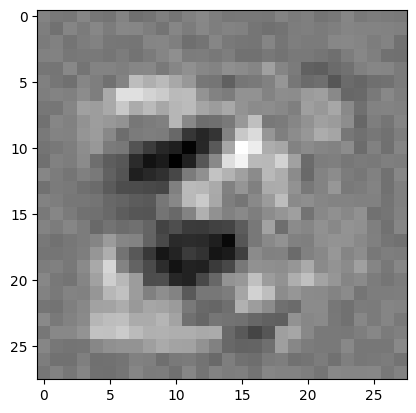

In [59]:
weights = model.state_dict()['weight']
print('weights:', weights.shape)

bias = model.state_dict()['bias']
print('bias:   ', bias.shape)

# Visualizando pesos da classe 3
plt.imshow(weights[3, :].numpy().reshape((28,28)),cmap = 'gray')
plt.show()

### Visualizando os pesos de todas as classes

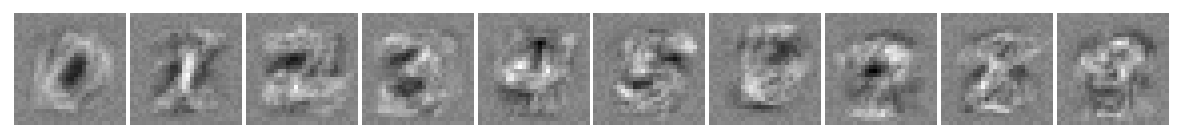

In [60]:
# cria um grid com as imagens
grid = torchvision.utils.make_grid(weights.view(-1, 1, 28, 28), normalize=True, pad_value=1.0, padding=1, nrow=10)

plt.figure(figsize=(15, 10))
plt.imshow(grid.numpy().transpose(1, 2, 0))
plt.axis('off');

### Diagrama da regressão softmax com visualização dos pesos W

![alt text](https://raw.githubusercontent.com/vcasadei/images/master/RegressaoSoftmaxArgmaxNMIST.png)

# Atividades

## Exercícios

- 1) Insira código no laço do treinamento para que no final de cada época,
     seja impresso: o número da época e a perda e a acurácia

- 2) Insira código no laço do treinamento para visualização dos valores dos gradientes referentes à classe do dígito 4, no final de cada época.

<details>
<summary>Mostrar Resultado</summary>

```python
losses = []
import numpy

import numpy
zs = []

for i in range(epochs):
    # Transforma a entrada para uma dimensão
    inputs = Variable(x_train.view(-1, 28 * 28))
    # Predict da rede
    outputs = model(inputs)
    
    # z0 a z9
    zs.append(outputs[1].detach().numpy())

    # calcula a perda
    loss = criterion(outputs, Variable(y_train))

    # zero, backpropagation, ajusta parâmetros pelo gradiente descendente
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())
    
    _, predicts = torch.max(outputs, 1)
    
    y_pred = predicts.data
    accuracy = (y_pred.numpy() == y_train.numpy()).mean()
    
    print('Epoch[{}/{}], loss: {:.6f}, acc: {:.6f}'
              .format(i+1, epochs, loss.data, accuracy))
    
    weights = model.state_dict()['weight']
    print('weights:', weights.shape)

    bias = model.state_dict()['bias']
    print('bias:   ', bias.shape)

    # Visualizando pesos da classe 3
    plt.imshow(weights[4, :].numpy().reshape((28,28)),cmap = 'gray')
    plt.show()
```

</details>

## Perguntas

1. Qual é o shape da matriz de entrada na rede?
2. Qual é o shape da saída da rede?
3. Qual é o número total de parâmetros da rede, incluindo o bias?

# Aprendizados
